In [19]:
import matplotlib.pyplot as plt
import numpy as np
import cmath as cmath
from qiskit.visualization import circuit_drawer, plot_histogram, plot_circuit_layout
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.circuit.library.standard_gates import RYGate
import combineandconquer as cac


# Quickstart

This notebook provides a few example to how the divide/combine-and-conquer can be implemented using qiskit. <br> The full code is available in the file <code>combineandconquer.py</code>, here we will just call the final function <code>CombineandConquer()</code> to show what can be done with it.

## Example 1: Basic Divide-and-conquer circuit

The default of the <code>CombineandConquer()</code> is the divide-and-conquer circuit. To implement this call the <code>CombineandConquer()</code> function with just the input vector you wish to encode. Here we use the example state of length 8. <br>
$$N=8 \rightarrow n=log_2(8)=3$$

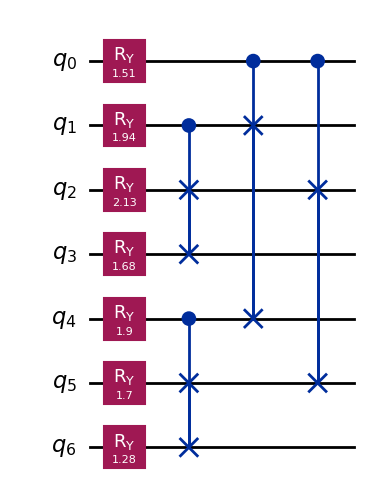

In [20]:
input_1 = [np.sqrt(0.04), 
           np.sqrt(0.13),
           np.sqrt(0.16),
           np.sqrt(0.2),
           np.sqrt(0.07),
           np.sqrt(0.09), 
           np.sqrt(0.2),
           np.sqrt(0.11)
           ]

circuit_1 = cac.CombineandConquer(input_1)

circuit_1.draw("mpl",plot_barriers=False)

## Example 2: Complex input

We can also have complex numbers as input, if this is the case we set complex to True when calling the function. Again we will use a $n=3$ example input.

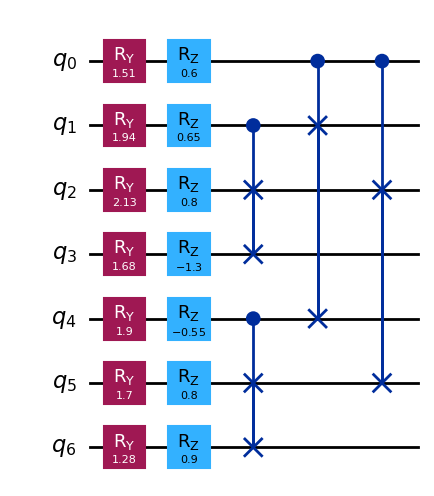

In [21]:
input_2 = [
    np.sqrt(0.04) * np.exp(1j * 0.3),
    np.sqrt(0.13) * np.exp(1j * 1.1),
    np.sqrt(0.16) * np.exp(1j * 2.0),
    np.sqrt(0.20) * np.exp(1j * 0.7),
    np.sqrt(0.07) * np.exp(1j * 1.5),
    np.sqrt(0.09) * np.exp(1j * 2.3),
    np.sqrt(0.20) * np.exp(1j * 0.9),
    np.sqrt(0.11) * np.exp(1j * 1.8)
]
circuit_2 = cac.CombineandConquer(input_2, complex=True)

circuit_2.draw("mpl",plot_barriers=False)

## Example 3: Combine-and-conquer

Finally, we can implement the combine-and-conquer circuit, by adding the parameter $\lambda$ we can modify the base module that will be combined in the divide-and-conquer circuit, allowing it to range from a single-qubit rotational gate to full circuit encoded by an alterative amplitude encoding method. <br>
We use an $n=4$ circuit to demonstrate.

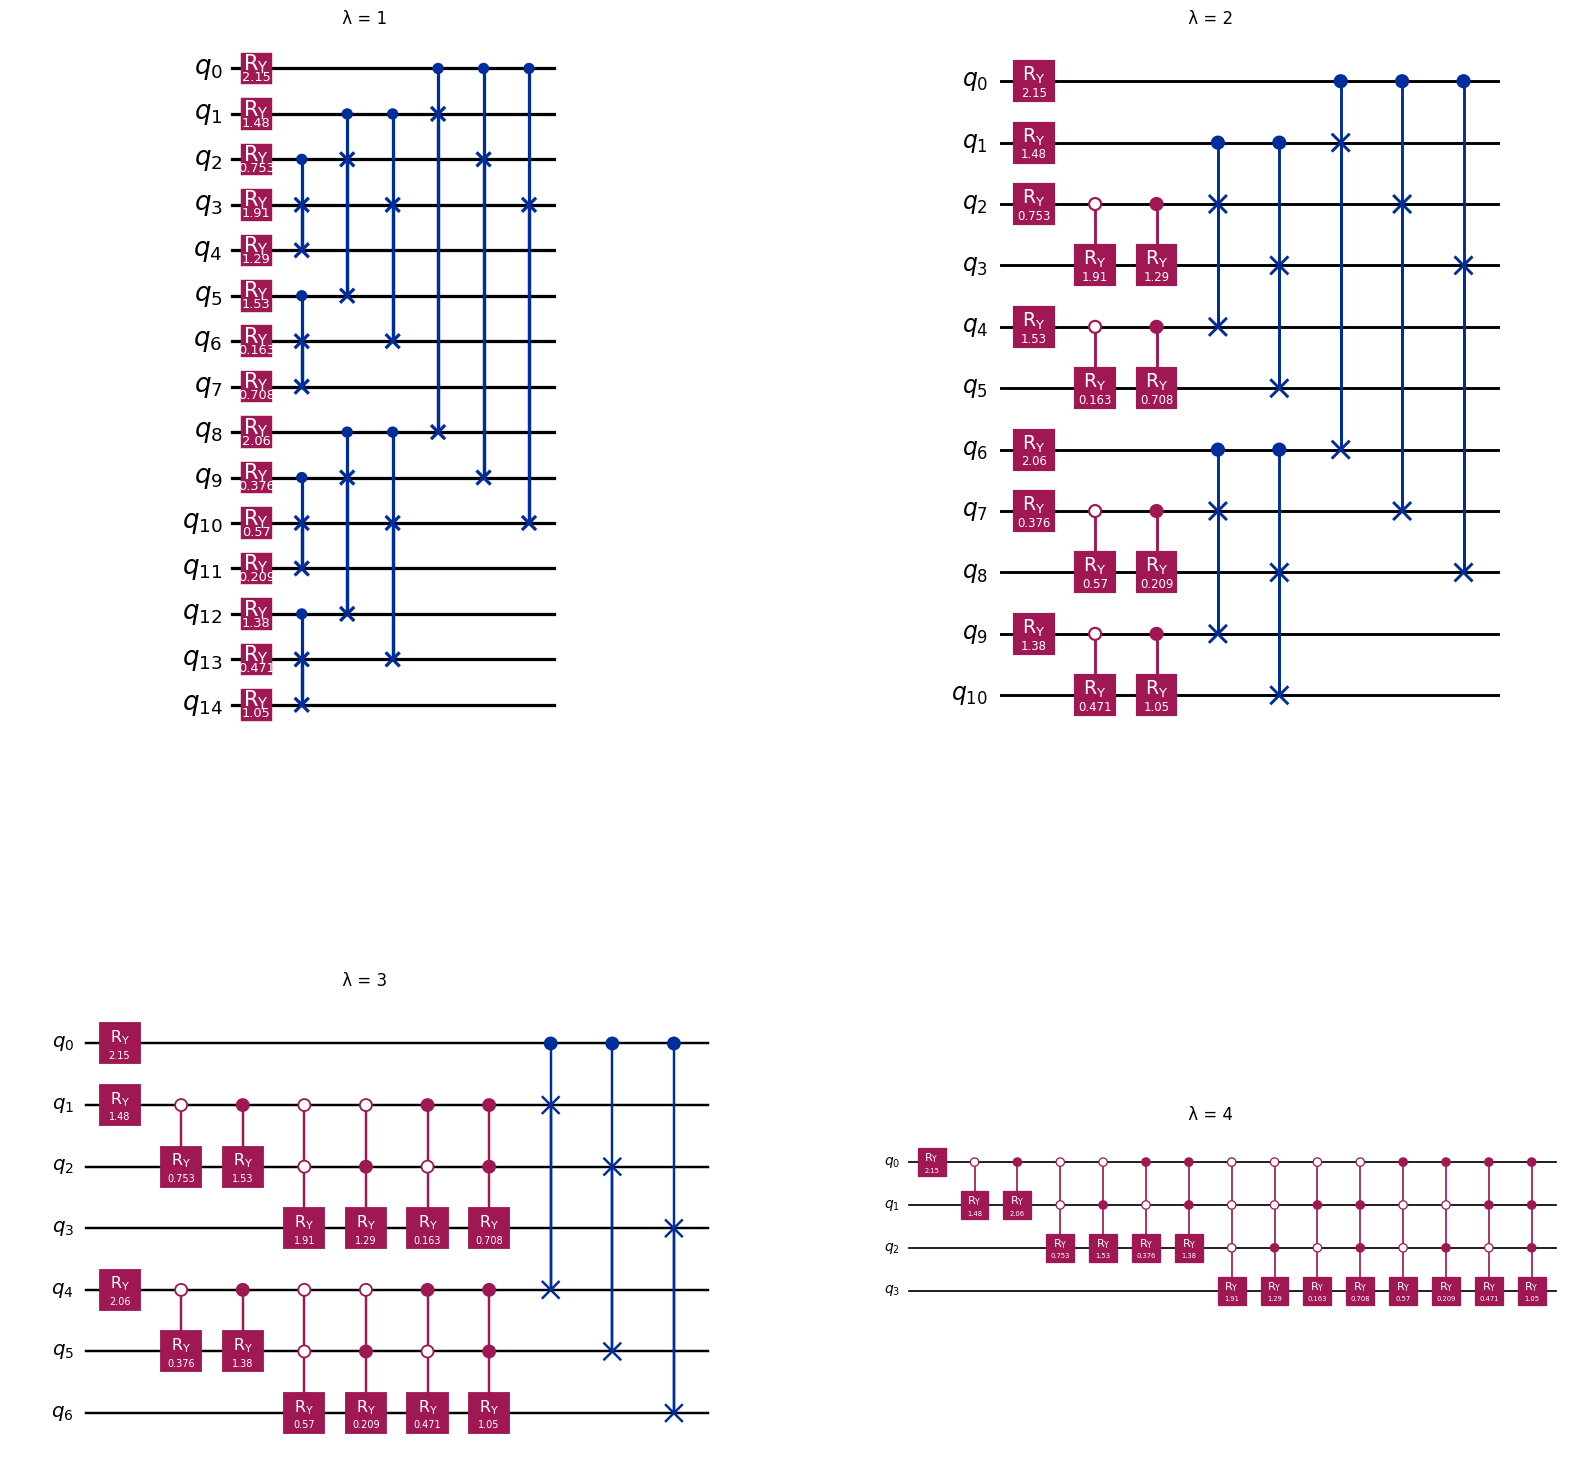

In [22]:
input_3 = np.random.randn(16)

circuit_3_1 = cac.CombineandConquer(input_3,1)
circuit_3_1 = cac.CombineandConquer(input_3,1)

fig, axs = plt.subplots(2, 2, figsize=(20, 20))
axs = axs.flatten()
for i, ax in enumerate(axs):
    circuit_drawer(cac.CombineandConquer(input_3,1+i), output='mpl',plot_barriers=False, ax=ax)
    ax.set_title(f" λ = {i+1}")


## Sanity Check
We can check that the circuits are providing the right output by running it, we will use the simulated backend that qiskit provide on circuit_1 

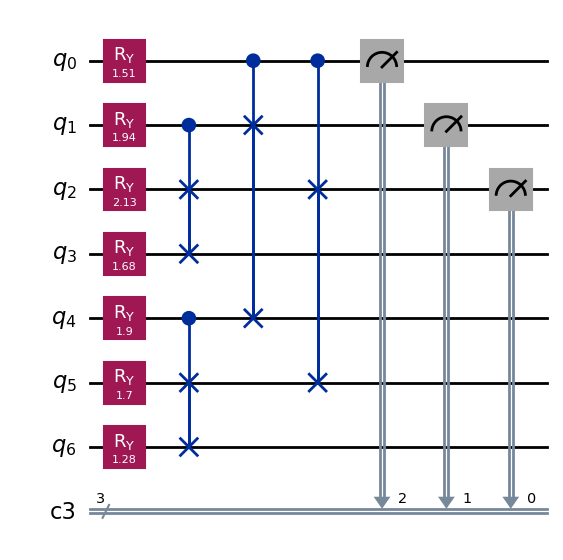

In [23]:
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram


circuit_4 = cac.CombineandConquer(input_1)
#add classical bit to measure unto
circuit_4.add_register(ClassicalRegister(3))
# qiskit conventions means that the first qubit is the least significant bit
# to counter that we measure onto the classical bits in reverse order
for i in range(3):
    circuit_4.measure(i,3-i-1)

circuit_4.draw("mpl",plot_barriers=False)



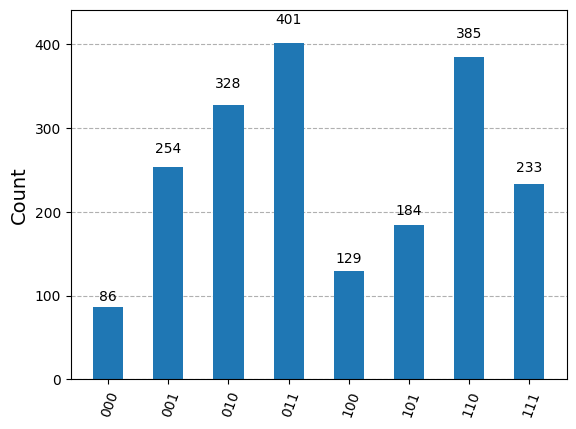

In [46]:

simulator_basic = BasicSimulator()

shots = 2000
result = simulator_basic.run(circuit_4, shots=shots).result()
counts = result.get_counts()

plot_histogram(counts)

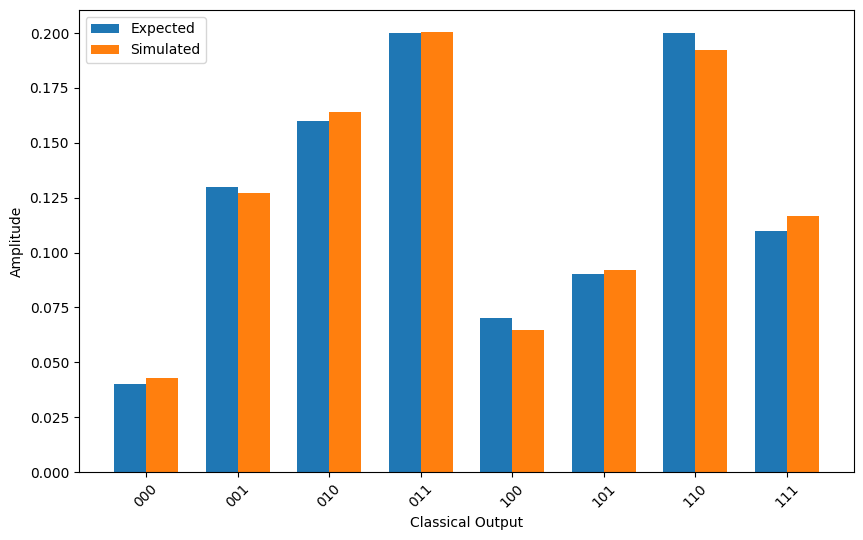

In [47]:
# It's not clear that we get the desired state until we normalise the counts


countlist = cac.GenBinaryStrings(3)

def AddKey(dictionary, key):
    if key not in dictionary:
        dictionary[key] = 0

for n in countlist:
    AddKey(counts, n)



Keys = list(counts.keys())
Keys.sort()
output = {key: counts[key] for key in Keys}


input_values = [(i**2) for i in input_1]
simulated_values = [(i/shots) for i in output.values()]
bits =  [i for i in output.keys()]



fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
x1 = np.arange(len(bits))

ax.bar(x1 - width/2, input_values, width, label='Expected')
ax.bar(x1 + width/2, simulated_values,  width, label='Simulated')


ax.tick_params(axis='both')  
ax.set_xticks(x1)
ax.set_xticklabels(bits)
plt.xticks(rotation = 45) 
plt.xlabel("Classical Output")
plt.ylabel("Amplitude")

plt.legend().get_frame().set_facecolor('None')
plt.show()

